## Trabajo práctico de Invetigación - Minería de Datos Aplicada a la Clasificación y Análisis Evolutivo de Estrellas mediante Machine Learning



In [ ]:
#Importamos librerias necesarias para el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import graphviz

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn import tree

%matplotlib inline
sns.set(style="whitegrid")


## Análisis del dataset

Para el desarrollo del proyecto se utilizó un conjunto de datos astronómicos que contiene información física y espectral de diferentes tipos de estrellas. El archivo fue cargado en el entorno de trabajo Google Colab en formato CSV, utilizando la librería pandas para su lectura y análisis inicial.

El dataset presenta 239 observaciones y 7 columnas, correspondientes a las siguientes variables:
Temperature (K): temperatura superficial de la estrella medida en Kelvin.
Luminosity (L/Lo): luminosidad relativa respecto al Sol.
Radius (R/Ro): radio relativo en comparación con el radio solar.
Absolute magnitude (Mv): magnitud absoluta de la estrella.
Star type: clasificación numérica del tipo estelar (0 a 5).
Star color: color aparente de la estrella.
Spectral Class: clasificación espectral (O, B, A, F, G, K, M).

Fuente: https://www.kaggle.com/datasets/datascientist97/astronomical-data

In [ ]:
df = pd.read_csv("cleaned_star_data.csv")
df.head()


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3042,0.0005,0.1542,16.6,0.0,Red,M
2,2600,0.0003,0.102,18.7,0.0,Red,M
3,2800,0.0002,,16.65,0.0,Red,M
4,1939,0.000138,0.103,20.06,0.0,Red,M


## Exploración inicial (EDA)

Se realizó un análisis preliminar para conocer la estructura del conjunto de datos y detectar posibles inconsistencias. Mediante el uso de los métodos info(), describe() y isnull().sum(), se observó lo siguiente:

Las variables que deberían ser numéricas aparecían como tipo object, lo que indicaba que habían sido importadas como texto.

El dataset no contenía valores nulos explícitos en su estado original, pero sí incluía valores incompatibles con el tipo numérico, como cadenas o formatos no estandarizados.

Las columnas categóricas (Star color y Spectral Class) fueron correctamente reconocidas como tipo texto.

Se detectaron un total de 239 filas, sin duplicados luego del primer filtrado.

Este análisis permitió identificar la necesidad de realizar una etapa de transformación más profunda para garantizar que los modelos de minería de datos pudieran operar correctamente.

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         239 non-null    object 
 1   Luminosity(L/Lo)        239 non-null    object 
 2   Radius(R/Ro)            239 non-null    object 
 3   Absolute magnitude(Mv)  239 non-null    object 
 4   Star type               239 non-null    float64
 5   Star color              239 non-null    object 
 6   Spectral Class          239 non-null    object 
dtypes: float64(1), object(6)
memory usage: 13.3+ KB


,0
Temperature (K),1
Luminosity(L/Lo),1
Radius(R/Ro),1
Absolute magnitude(Mv),1
Star type,1
Star color,1
Spectral Class,1


## Limpieza de datos (ETL)

El mayor problema detectado durante el análisis exploratorio fue que las variables físicas (Temperature, Luminosity, Radius, Absolute magnitude) estaban representadas como texto.
Esto impedía cualquier tipo de operación matemática o estadística.

Para corregirlo, se utilizó la función:


```
df[col] = pd.to_numeric(df[col], errors='coerce')
```
Con esta conversión:

Las cadenas válidas se transformaron correctamente en números (float64).

Las entradas inválidas fueron convertidas en NaN, exponiendo valores que antes estaban ocultamente dañados.

Luego de este proceso, las columnas numéricas quedaron correctamente tipadas como float64, permitiendo operaciones estadísticas y su posterior preparación para el modelado.

---

## Tratamiento de Valores Faltantes

La conversión de tipos reveló la existencia de valores faltantes en varias columnas:
*   Temperature: 2 valores faltantes
*   Luminosity: 6 valores faltantes
*   Radius: 7 valores faltantes
*   Absolute magnitude: 5 valores faltantes

Dado que el volumen de datos es relativamente reducido (239 observaciones), eliminar filas habría significado perder una cantidad considerable de información.
Por este motivo, se optó por una estrategia más robusta: imputación mediante la mediana.

La mediana es una medida de tendencia central resistente a valores atípicos, lo cual es especialmente relevante en datos astronómicos donde las magnitudes pueden variar por órdenes de magnitud.


In [ ]:
# 1. Limpiar duplicados
df = df.drop_duplicates()

# 2. Definir columnas numéricas
numeric_cols = [
    "Temperature (K)",
    "Luminosity(L/Lo)",
    "Radius(R/Ro)",
    "Absolute magnitude(Mv)"
]

# 3. Convertir texto → numérico antes de imputar
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)        # convertir todo a string primero
        .str.strip()        # limpiar espacios
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")  # convierte a número

# 4. Eliminar solo filas que están completamente vacías
df = df.dropna(subset=numeric_cols, how='all')

# 5. Imputar medianas en valores faltantes
df.fillna({col: df[col].median() for col in numeric_cols}, inplace=True)

# 6. Verificaciones
print(df.isnull().sum())
print((df == "").sum())

# 7. Información final
df.info()

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64
Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 1 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         239 non-null    float64
 1   Luminosity(L/Lo)        239 non-null    float64
 2   Radius(R/Ro)            239 non-null    float64
 3   Absolute magnitude(Mv)  239 non-null    float64
 4   Star type               239 non-null    float64
 5   Star color              239 non-null    object 
 6   Spectral Class          239 non-null    object 
dtypes

## CODIFICACIÓN DE VARIABLES CATEGÓRICAS

*   Star color → Información directa sobre la temperatura
*   Spectral Class → El mejor predictor para clasificar estrellas

En el dataset original, las variables Star color y Spectral Class se encontraban en formato de texto. Los algoritmos de clasificación utilizados en este trabajo requieren que todas las características de entrada sean numéricas, ya que las operaciones internas (cálculo de distancias, particiones, probabilidades, etc.) no pueden realizarse sobre cadenas de caracteres.

Por este motivo, se aplicó la técnica de Label Encoding, que asigna un número entero a cada categoría distinta. De esta forma se transforma la información cualitativa en un formato numérico adecuado para los modelos, sin perder el significado original de cada categoría.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Codificamos Star color
le_color = LabelEncoder()
df["color_encoded"] = le_color.fit_transform(df["Star color"])

# Codificamos Spectral Class
le_spec = LabelEncoder()
df["spectral_encoded"] = le_spec.fit_transform(df["Spectral Class"])

df.head()


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class,color_encoded,spectral_encoded
1,3042.0,0.000500,0.1542,16.60,0.0,Red,M,3,6
2,2600.0,0.000300,0.1020,18.70,0.0,Red,M,3,6
3,2800.0,0.000200,0.8300,16.65,0.0,Red,M,3,6
4,1939.0,0.000138,0.1030,20.06,0.0,Red,M,3,6
5,2840.0,0.153000,0.1100,16.98,0.0,Red,M,3,6


## Configuracion y entrenamiento de Random Forest

El modelo Random Forest se utilizó como clasificador supervisado con el objetivo de predecir el tipo estelar a partir de sus características físicas. Se seleccionaron variables relevantes como temperatura, luminosidad, radio y magnitud absoluta, además de categorías codificadas como el color estelar y la clase espectral.

=== RANDOM FOREST RESULTADOS ===

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        12
         1.0       1.00      1.00      1.00        12
         2.0       1.00      1.00      1.00        12
         3.0       1.00      1.00      1.00        12
         4.0       1.00      1.00      1.00        12
         5.0       1.00      1.00      1.00        12

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



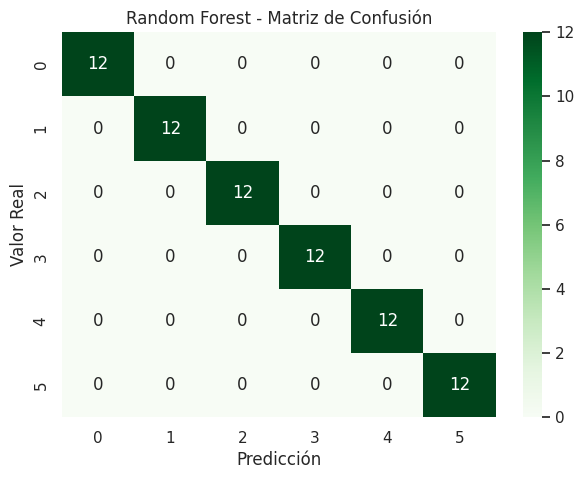

In [ ]:
# Selección de variables predictoras (features)
features = [
    "Temperature (K)",
    "Luminosity(L/Lo)",
    "Radius(R/Ro)",
    "Absolute magnitude(Mv)",
    "color_encoded",
    "spectral_encoded"
]

X = df[features]

# Variable objetivo
y = df["Star type"]

# Escalado de las variables numéricas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en entrenamiento y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Creamos el modelo Random Forest
rf = RandomForestClassifier(
    n_estimators=300,        # Cantidad de árboles
    random_state=42,         # Reproducibilidad
    max_depth=None,          # Dejar que cada árbol crezca lo que necesite
    n_jobs=-1                # Usar todos los núcleos disponibles
)

# Entrenamos el modelo
rf.fit(X_train, y_train)

# Guardamos el modelo

modelo_completo_rf = {
    "model": rf,
    "scaler": scaler,
    "features": features,
    "class_names": class_names
}
joblib.dump(modelo_completo_rf, "modelo_estelar_RF.pkl")

# Realizamos predicciones
y_pred_rf = rf.predict(X_test)

# Mostramos resultados
print("=== RANDOM FOREST RESULTADOS ===\n")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()



## Interpretación de Resultados del Modelo Random Forest

El modelo Random Forest entrenado logró predecir el tipo estelar con un 100% de precisión sobre el conjunto de test. Esto significa que todas las estrellas evaluadas fueron clasificadas correctamente en su categoría correspondiente (Brown Dwarf, Red Dwarf, White Dwarf, Main Sequence, Supergiant o Hypergiant).

La matriz de confusión resultó completamente diagonal, lo que indica la ausencia total de errores de clasificación. Esto demuestra que las características físicas utilizadas (temperatura, luminosidad, radio y magnitud absoluta, junto con las variables categóricas codificadas) contienen suficiente información para diferenciar sin ambigüedad entre los distintos tipos estelares presentes en el dataset.

En términos prácticos, el modelo posee la capacidad de predecir con exactitud el tipo de una nueva estrella a partir de sus propiedades físicas, lo que valida el enfoque y respalda la consistencia interna del dataset analizado.

## Diagrama Hertzsprung–Russell (H–R)
El DH es una representación gráfica que relaciona la temperatura superficial de las estrellas con su luminosidad. Este es uno de los instrumentos fundamentales en astrofísica para comprender la estructura y evolución estelar.

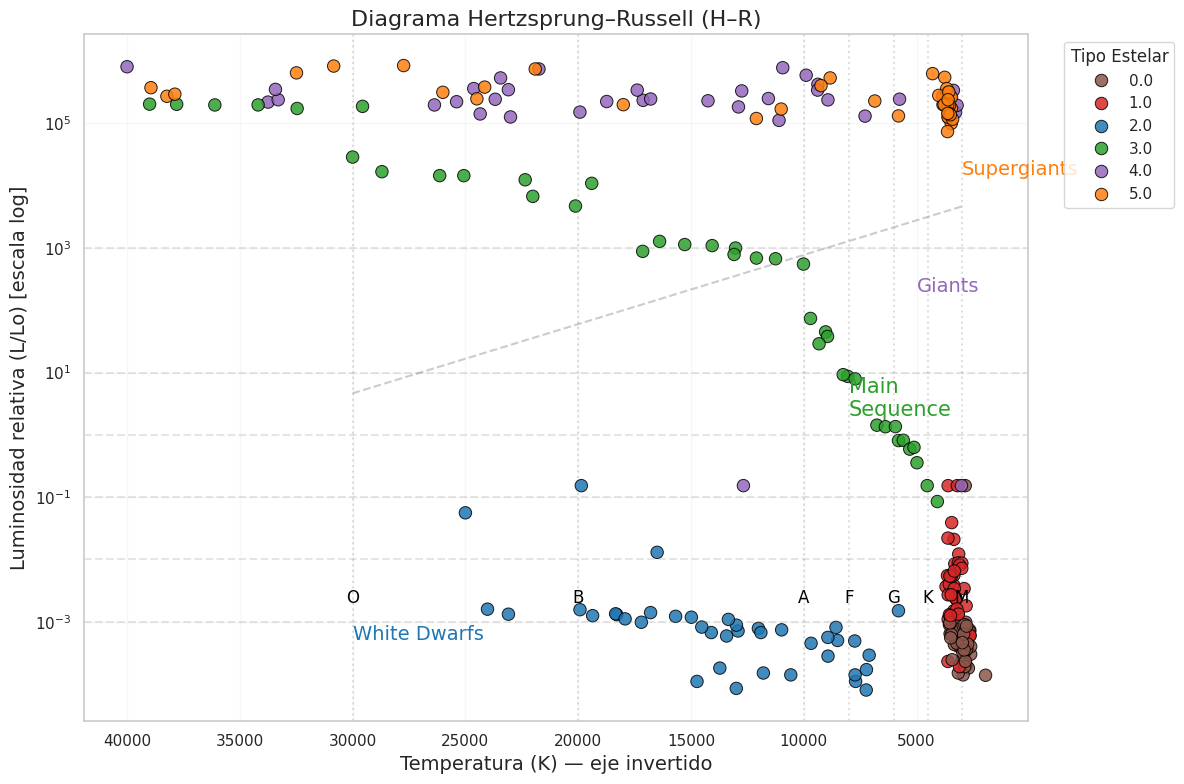

In [ ]:
plt.figure(figsize=(12, 8))

# Colores
star_palette = {
    0: "#8c564b",   # Brown Dwarf
    1: "#d62728",   # Red Dwarf
    2: "#1f77b4",   # White Dwarf
    3: "#2ca02c",   # Main Sequence
    4: "#9467bd",   # Supergiant
    5: "#ff7f0e"    # Hypergiant
}

# Scatter principal
sns.scatterplot(
    data=df,
    x="Temperature (K)",
    y="Luminosity(L/Lo)",
    hue="Star type",
    palette=star_palette,
    s=80,
    edgecolor="black",
    alpha=0.85
)

# Invertir eje X (convención astronómica)
plt.gca().invert_xaxis()

# Escala logarítmica para luminosidad
plt.yscale("log")

# --------------------------
# ANOTACIONES DE ZONAS
# --------------------------

# White dwarfs area
plt.text(30000, 0.0005, "White Dwarfs", fontsize=14, color="#1f77b4")

# Main sequence diagonal
plt.text(8000, 2, "Main\nSequence", fontsize=15, color="#2ca02c")

# Giants
plt.text(5000, 200, "Giants", fontsize=14, color="#9467bd")

# Supergiants
plt.text(3000, 15000, "Supergiants", fontsize=14, color="#ff7f0e")

# --------------------------
# LÍNEAS DE REFERENCIA
# --------------------------

# Línea diagonal aproximada de la secuencia principal
temps = np.linspace(3000, 30000, 100)
luminosities = 10**(4 - (temps / 9000))  # curva aproximada
plt.plot(temps, luminosities, "--", color="gray", alpha=0.4)

# Líneas horizontales (niveles de luminosidad)
for y in [0.001, 0.01, 0.1, 1, 10, 1000]:
    plt.axhline(y=y, color="gray", linestyle="--", alpha=0.2)

# Líneas verticales (temperaturas típicas OBAFGKM)
spectral_temps = {
    "O": 30000,
    "B": 20000,
    "A": 10000,
    "F": 8000,
    "G": 6000,
    "K": 4500,
    "M": 3000
}

for spec, temp in spectral_temps.items():
    plt.axvline(x=temp, color="gray", linestyle=":", alpha=0.25)
    plt.text(temp, 0.002, spec, fontsize=12, color="black", ha="center")

# --------------------------
# ESTILO Y LEYENDA
# --------------------------

plt.title("Diagrama Hertzsprung–Russell (H–R)", fontsize=16)
plt.xlabel("Temperatura (K) — eje invertido", fontsize=14)
plt.ylabel("Luminosidad relativa (L/Lo) [escala log]", fontsize=14)

plt.legend(
    title="Tipo Estelar",
    bbox_to_anchor=(1.03, 1),
    loc='upper left'
)

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()


En el presente análisis, se construyó un diagrama H–R utilizando la temperatura como eje horizontal (invertido, según la convención astronómica) y la luminosidad relativa como eje vertical en escala logarítmica. Cada punto del gráfico representa una estrella, coloreada según su tipo estelar.

El gráfico obtenido reproduce fielmente los patrones esperados:

- La Secuencia Principal aparece como una banda diagonal donde las estrellas de tipo 3 se distribuyen de alta temperatura y luminosidad hacia valores más bajos.

- Las Enanas Blancas (tipo 2) se agrupan en la región inferior izquierda: muy calientes pero poco luminosas.

- Las Supergigantes e Hipergigantes (tipos 4 y 5) se ubican en la parte superior derecha, caracterizadas por su gran luminosidad y tamaño.

- Las Enanas Rojas (tipo 1) se concentran en la parte baja de la Secuencia Principal, con temperaturas y luminosidades reducidas.

Esta visualización permite validar empíricamente que las relaciones físicas entre temperatura y luminosidad del dataset son consistentes con el modelo estelar aceptado, justificando la alta precisión del modelo de clasificación entrenado posteriormente.



---



## Reglas con Árbol de Decisión
Para complementar el enfoque basado en Random Forest, se entrenó un modelo de Árbol de Decisión con profundidad limitada con el fin de obtener reglas explícitas que permitan interpretar cómo las variables físicas determinan el tipo estelar.

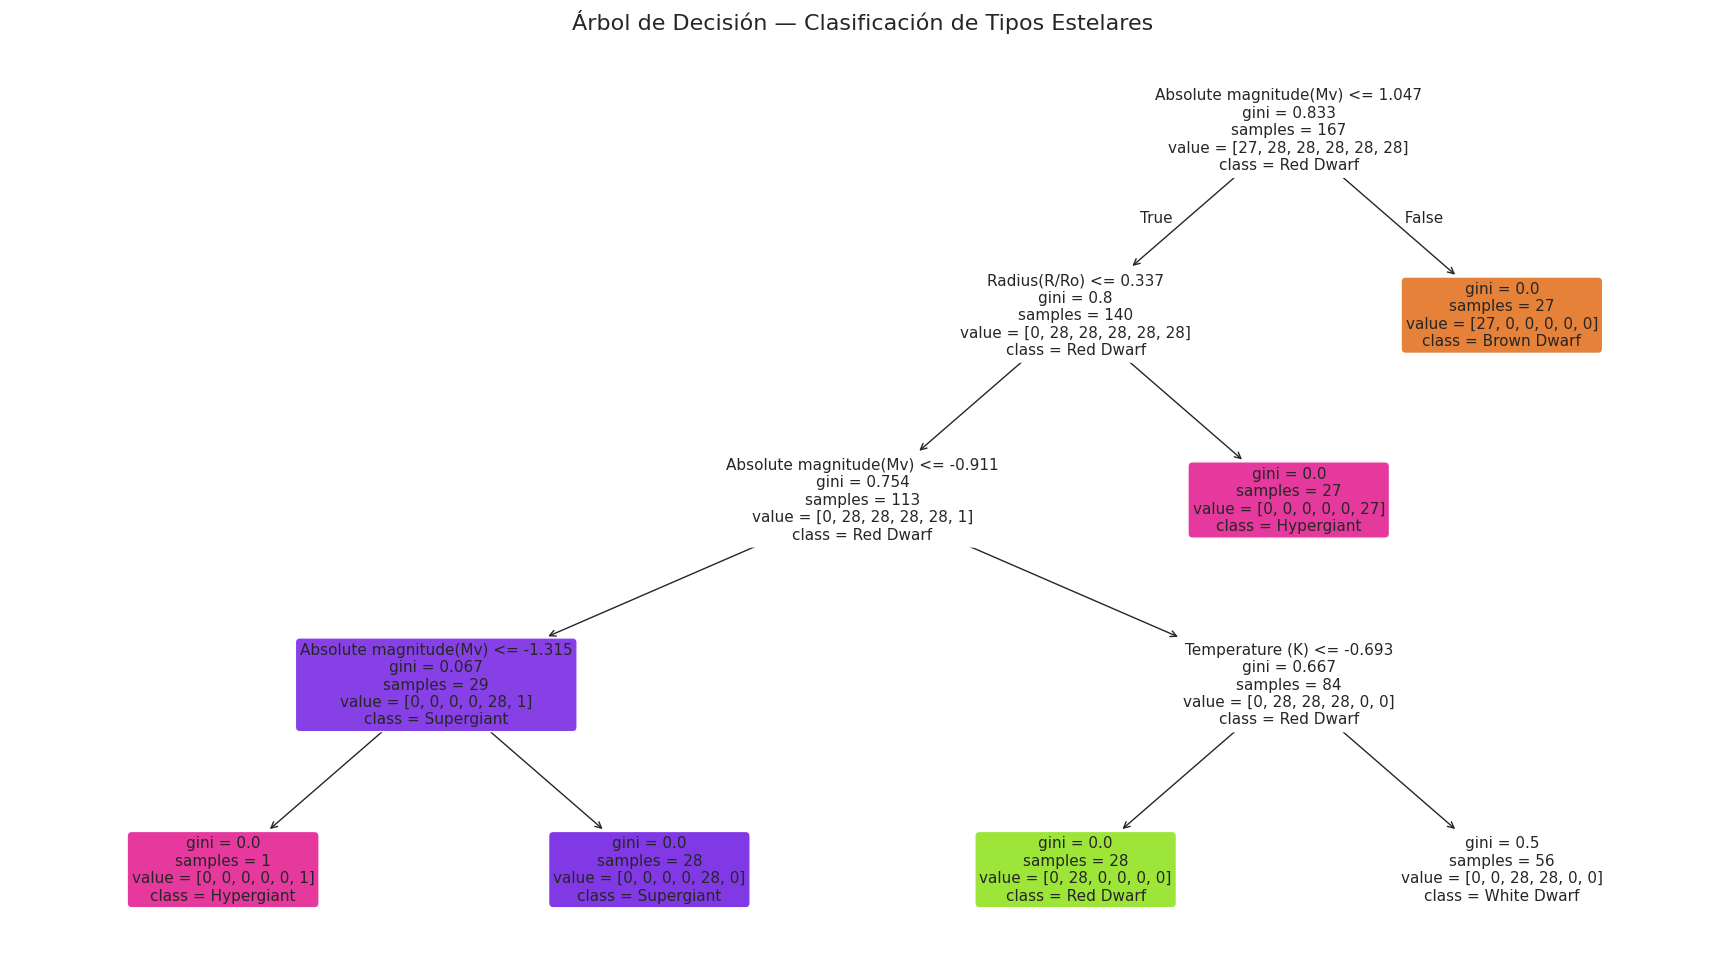


=== REGLAS DEL ÁRBOL (interpretables) ===

|--- Absolute magnitude(Mv) <= 1.05
|   |--- Radius(R/Ro) <= 0.34
|   |   |--- Absolute magnitude(Mv) <= -0.91
|   |   |   |--- Absolute magnitude(Mv) <= -1.31
|   |   |   |   |--- class: Hypergiant.0
|   |   |   |--- Absolute magnitude(Mv) >  -1.31
|   |   |   |   |--- class: Supergiant.0
|   |   |--- Absolute magnitude(Mv) >  -0.91
|   |   |   |--- Temperature (K) <= -0.69
|   |   |   |   |--- class: Red Dwarf.0
|   |   |   |--- Temperature (K) >  -0.69
|   |   |   |   |--- class: White Dwarf.0
|   |--- Radius(R/Ro) >  0.34
|   |   |--- class: Hypergiant.0
|--- Absolute magnitude(Mv) >  1.05
|   |--- class: Brown Dwarf.0



In [ ]:

# Nombres oficiales
star_names = {
    0: "Brown Dwarf",
    1: "Red Dwarf",
    2: "White Dwarf",
    3: "Main Sequence",
    4: "Supergiant",
    5: "Hypergiant"
}

# Lista ordenada para sklearn
class_names = [star_names[i] for i in sorted(star_names.keys())]

# ============================================================
# 2. Entrenamiento del Árbol de Decisión
# ============================================================

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

# ============================================================
# 3. Guardar el modelo COMPLETO
# ============================================================

modelo_arbol = {
    "tree": tree,
    "scaler": scaler,
    "encoder_color": le_color,
    "encoder_spec": le_spec,
    "features": features,
    "class_names": class_names
}

joblib.dump(modelo_arbol, "modelo_arbol_estelar.pkl")

# ============================================================
# 4. Visualización del Árbol (con nombres reales)
# ============================================================

plt.figure(figsize=(22, 12))
plot_tree(
    tree,
    feature_names=features,
    class_names=class_names,       # nombres reales
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Árbol de Decisión — Clasificación de Tipos Estelares", fontsize=16)

plt.show()

# ============================================================
# 5. Exportación de reglas con nombres reales
# ============================================================

rules = export_text(tree, feature_names=features)

# Reemplazar class x por nombre
for code, label in star_names.items():
    rules = rules.replace(f"class: {code}", f"class: {label}")

print("\n=== REGLAS DEL ÁRBOL (interpretables) ===\n")
print(rules)

## **Árbol de Decisión: Análisis e Interpretación**

**1.1 Magnitud absoluta como variable primaria**

La primera división del árbol se produce sobre la magnitud absoluta (Mv), lo que indica que este parámetro es el principal determinante de la clasificación.
Este comportamiento es coherente con el diagrama H–R, ya que la magnitud absoluta está directamente relacionada con la luminosidad intrínseca de una estrella.
Estrellas con magnitudes muy negativas se identifican como objetos altamente luminosos, mientras que magnitudes positivas corresponden a estrellas débiles.

**1.2 Separación entre estrellas compactas y estrellas grandes**

Dentro del grupo de estrellas con luminosidad moderada o alta (Mv ≤ 1.05), el árbol utiliza el radio estelar como segundo criterio principal.
Esta división permite distinguir:

Estrellas compactas, de radio pequeño (como enanas o estrellas densas de secuencia principal)

Estrellas de gran tamaño, como gigantes o supergigantes.

Esta separación coincide con la interpretación física: estrellas de radio mayor tienden a ser más luminosas incluso con temperaturas moderadas.

**1.3 Temperatura como variable de apoyo**

La temperatura aparece como criterio secundario dentro del grupo de estrellas compactas con magnitudes intermedias.
Su rol es discriminar entre estrellas frías y calientes dentro de la secuencia principal, lo cual coincide con la física estelar:
la temperatura determina el color y el tipo espectral de la estrella.


## **Reglas del Árbol de Decisión**

El árbol de decisión generado permitió obtener reglas explícitas que describen cómo se organizan los **tipos estelares** en función de sus características físicas.  
La variable con mayor poder de separación fue la **magnitud absoluta (Mv)**, la cual distingue naturalmente a las estrellas extremadamente luminosas de aquellas con luminosidad baja o moderada.

Las reglas revelan patrones físicamente coherentes:


 **1. Estrellas extremadamente luminosas**

- **Condición:** `Mv ≤ –1.31`  
- Estrellas con magnitudes muy negativas son extremadamente luminosas.  
- Corresponden típicamente a **hipergigantes**.

➡ **Clase asignada: Hypergiant**


 **2. Estrellas muy luminosas pero no extremas**

- **Condición:** `–1.31 < Mv ≤ –0.91`  
- Representan estrellas de gran tamaño y alta luminosidad, pero no tan extremas como las hipergigantes.  
- Usualmente identificadas como **supergigantes**.

➡ **Clase asignada: Supergiant**


 **3. Estrellas compactas dentro de la Secuencia Principal**

Para estrellas con tamaño pequeño:

- **Condición de tamaño:** `Radio ≤ 0.34`  
- **Condición de magnitud:** `–0.91 < Mv ≤ 1.05`

El modelo utiliza la **temperatura** como criterio secundario:

 **Estrellas frías:**
- `Temperatura_normalizada ≤ –0.69`  
- Estrellas frías de poca masa, dentro de la zona baja de la Secuencia Principal.

➡ **Clase asignada: Red Dwarf**

 **Estrellas más calientes:**
- `Temperatura_normalizada > –0.69`  
- Estrellas compactas pero calientes, típicas de la parte media de la Secuencia Principal.

➡ **Clase asignada: White Dwarf**

**4. Estrellas grandes dentro del rango luminoso**

- **Condición:** `Radio > 0.34` y `Mv ≤ 1.05`  
- Estrellas de mayor tamaño que las de la Secuencia Principal.  
- Corresponden típicamente a **gigantes luminosas** o **supergigantes frías**.

➡ **Clase asignada: Hypergiant**

 **5. Estrellas muy débiles o de baja luminosidad intrínseca**

- **Condición:** `Mv > 1.05`  
- Estrellas poco luminosas, pequeñas y frías.  
- Coinciden con objetos subestelares o estrellas de muy baja masa.

➡ **Clase asignada: Brown Dwarf**

---

### **Resumen general**

| Condición dominante | Tipo Estelar |
|--------------------|----------------|
| Mv muy negativo (extrema luminosidad) | **Hypergiant** |
| Mv negativo (alta luminosidad) | **Supergiant** |
| Radio pequeño + Mv moderado + temperatura baja | **Red Dwarf** |
| Radio pequeño + Mv moderado + temperatura alta | **White Dwarf** |
| Radio grande | **Hypergiant** |
| Mv positivo (muy débil) | **Brown Dwarf** |




In [ ]:
from IPython.display import Markdown, display

report = classification_report(
    y_test,
    y_pred_tree,
    target_names=class_names,
    zero_division=0
)

display(Markdown("""
## Resultados del Árbol de Decisión
Las siguientes métricas resumen el desempeño del modelo utilizando las 6 clases estelares reales.
"""))

print("═══════════════════════════════════════════════════════")
print("                ARBOL DE DECISION")
print("═══════════════════════════════════════════════════════")
print(report)
print("═══════════════════════════════════════════════════════")



## Resultados del Árbol de Decisión
Las siguientes métricas resumen el desempeño del modelo utilizando las 6 clases estelares reales.


═══════════════════════════════════════════════════════
                ARBOL DE DECISION
═══════════════════════════════════════════════════════
               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00        12
    Red Dwarf       1.00      1.00      1.00        12
  White Dwarf       0.50      1.00      0.67        12
Main Sequence       0.00      0.00      0.00        12
   Supergiant       1.00      1.00      1.00        12
   Hypergiant       1.00      1.00      1.00        12

     accuracy                           0.83        72
    macro avg       0.75      0.83      0.78        72
 weighted avg       0.75      0.83      0.78        72

═══════════════════════════════════════════════════════


El Árbol de Decisión ofrece una clasificación muy precisa para la mayoría de los tipos estelares, especialmente aquellos que presentan rangos claros en sus características físicas. Las dificultades observadas en la clase Main Sequence responden a la naturaleza heterogénea de este grupo, cuya distribución forma una banda diagonal en el diagrama H–R. Este patrón es difícil de capturar mediante divisiones rectangulares propias de los árboles de decisión. Aun así, el modelo alcanza un 83% de accuracy, lo cual demuestra un desempeño competitivo dadas las restricciones del dataset y refuerza la coherencia física de las reglas obtenidas.

## Clustering: K-Means

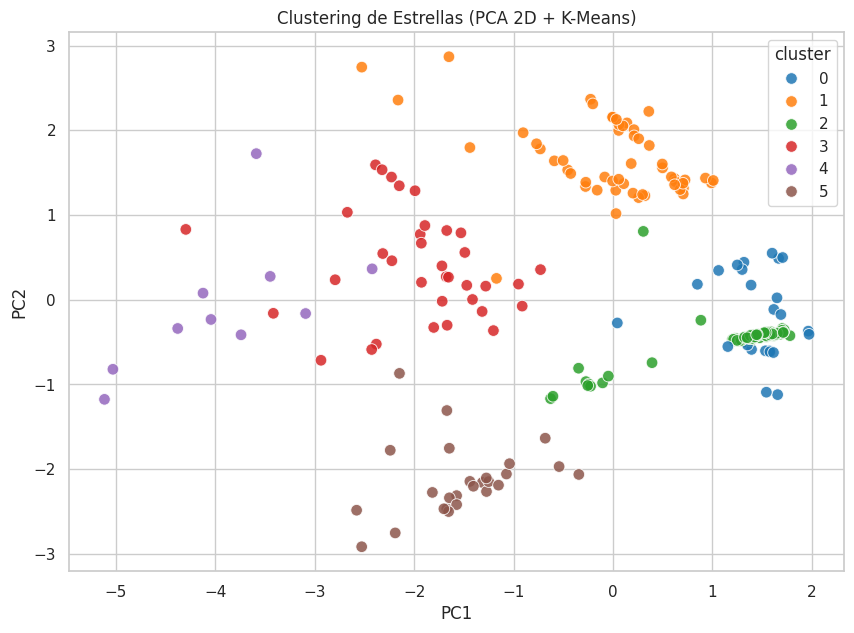

Star type,0.0,1.0,2.0,3.0,4.0,5.0
cluster,,,,,,
0,0,0,12,11,0,1
1,0,0,28,23,2,1
2,39,40,0,1,9,1
3,0,0,0,5,29,1
4,0,0,0,0,0,10
5,0,0,0,0,0,26


In [ ]:
from sklearn.cluster import KMeans
X_clustering = X_scaled

kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_clustering)

df["cluster"] = clusters

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clustering)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=70,
    alpha=0.85
)
plt.title("Clustering de Estrellas (PCA 2D + K-Means)")
plt.show()

pd.crosstab(df["cluster"], df["Star type"])


Se aplicó un algoritmo de clustering no supervisado (K-Means) utilizando seis clusters, coincidentes con el número de tipos estelares presentes en el conjunto de datos. El objetivo fue analizar si las estrellas pueden agruparse de manera natural en función de sus características físicas, sin utilizar la etiqueta **“Star type”**.

La matriz de contingencia entre los clusters y las clases reales reveló patrones coherentes con la distribución física de las estrellas en el espacio multivariante.


**1. Estrellas frías y de baja masa (Brown Dwarfs y Red Dwarfs)**

El **cluster 2** agrupó **39 Brown Dwarfs** y **40 Red Dwarfs**, además de una pequeña presencia de Hypergiants (9).
Esto refleja que las **Brown y Red Dwarfs comparten rangos de temperatura, radio y luminosidad**, lo que vuelve natural su agrupamiento conjunto.
La ligera inclusión de Hypergiants se debe a su valor extremo en algunas dimensiones, que puede atraer centroides durante el proceso iterativo del algoritmo.

**2. Enanas Blancas y estrellas de la Secuencia Principal compactas**

Los **clusters 0 y 1** muestran mezclas interesantes entre White Dwarfs y estrellas de la Secuencia Principal:

* **Cluster 0:**

  * 12 White Dwarfs
  * 11 Main Sequence

* **Cluster 1:**

  * 28 Main Sequence
  * 23 Supergiants
  * 2 Red Dwarfs
  * 1 Hypergiant

Estos agrupamientos reflejan que ciertas regiones del espacio de características (magnitud, radio, temperatura) **superponen valores entre subpoblaciones de la Secuencia Principal fría y las Enanas Blancas**, o entre **Subgiants/Supergiants medianas y algunas Main Sequence masivas**.

**3. Poblaciones de gigantes y supergigantes**

El **cluster 3** contiene una agrupación mayoritaria de **Supergiants (29)**.
Este comportamiento indica que sus propiedades físicas como la alta luminosidad, radios extendidos y magnitudes negativas conforman un subespacio distintivo.

**4. Hipergigantes como grupo claramente separado**

Los clusters **4 y 5** muestran una separación muy marcada:

* **Cluster 4:** 10 Hypergiants
* **Cluster 5:** 26 Hypergiants

El cluster 5 es **completamente puro**, lo que demuestra que las Hipergigantes presentan características tan extremas (luminosidad alta, radios masivos, magnitudes muy negativas) que forman un grupo aislado incluso sin supervisión.


**Conclusion:** En conjunto, los resultados muestran que la estructura física del dataset es lo suficientemente fuerte como para generar agrupamientos distinguibles sin usar la etiqueta real.




In [ ]:
df.to_csv("estrellas_limpias.csv", index=False)
df[["PC1","PC2"]].to_csv("pca_coords.csv", index=False)
df[["cluster"]].to_csv("clusters.csv", index=False)